In [1]:


import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import ( TimeSeriesSplit,cross_val_score,GridSearchCV )

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (LinearRegression,Ridge,Lasso)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.shape)

df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [6]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [7]:
print("Duplicates :", df.duplicated().sum())

Duplicates : 0


In [8]:
df["Date"] = pd.to_datetime(
    dict(year=df["Year"],
        month=df["Month"],
        day=1
    )
)

df = df.sort_values("Date")

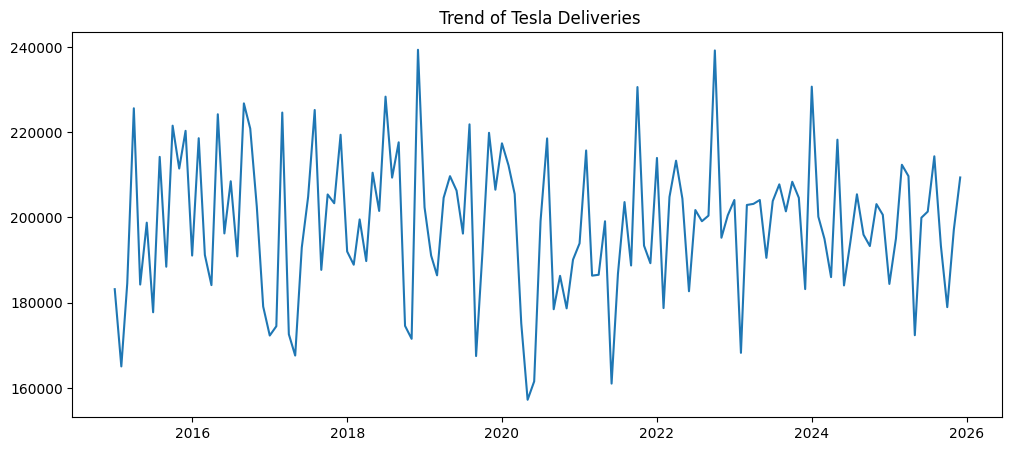

In [9]:
monthly = (
    df.groupby("Date")
    ["Estimated_Deliveries"]
    .sum()
)

plt.figure(figsize=(12,5))
plt.plot(monthly)
plt.title(" Trend of Tesla Deliveries")
plt.show()

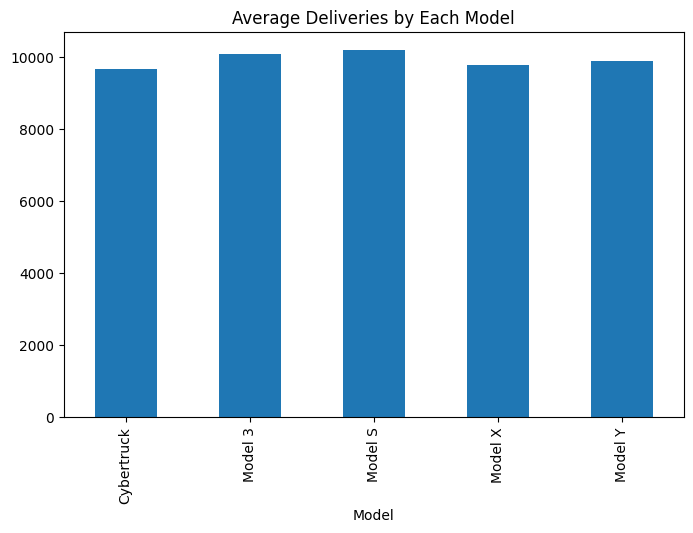

In [10]:
model_avg = (
    df.groupby("Model")
    ["Estimated_Deliveries"]
    .mean()
)

model_avg.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Deliveries by Each Model")

plt.show()

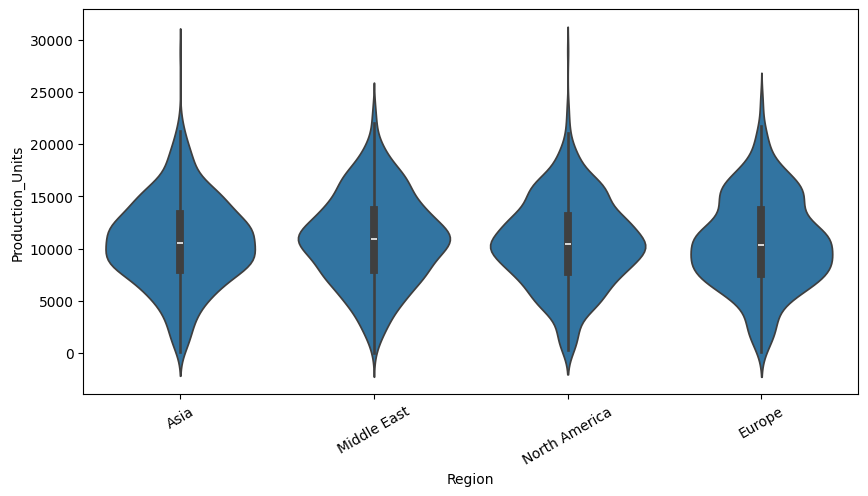

In [11]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x="Region",
    y="Production_Units",
    data=df
)

plt.xticks(rotation=30)

plt.show()

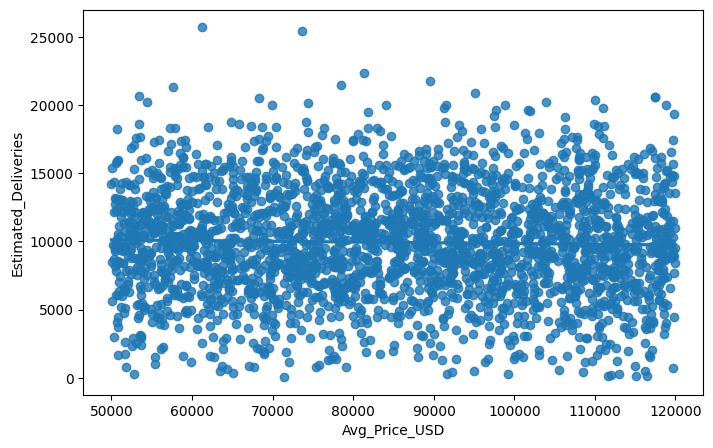

In [12]:
plt.figure(figsize=(8,5))

sns.regplot(
    x="Avg_Price_USD",
    y="Estimated_Deliveries",
    data=df
)

plt.show()

In [13]:
df["Growth_Rate"] = (
    df["Estimated_Deliveries"]
    .pct_change()
)

df["Growth_Rate"] = (
    df["Growth_Rate"]
    .fillna(0)
)

In [14]:
df["Lag_1"] = (
    df["Estimated_Deliveries"]
    .shift(1)
)

df["Lag_6"] = (
    df["Estimated_Deliveries"]
    .shift(6)
)

In [15]:
df["Rolling_Mean_6"] = (
    df["Estimated_Deliveries"]
    .rolling(6)
    .mean()
)

df["Rolling_Max_6"] = (
    df["Estimated_Deliveries"]
    .rolling(6)
    .max()
)

df["Quarter"] = (
    (df["Month"] - 1)//3
) + 1

In [16]:
df.fillna(method="bfill", inplace=True)

In [17]:
df = pd.get_dummies(
    df,
    columns=[
        "Region",
        "Model",
        "Source_Type"
    ],
    drop_first=True
)

In [18]:
target = "Estimated_Deliveries"

X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)

y = df[target]

In [19]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [21]:
def evaluate_model(actual,predicted):

    print("MAE:", mean_absolute_error( actual,predicted) )

    print("RMSE:", np.sqrt( mean_squared_error( actual, predicted )  ))

    print( "R2:",r2_score(  actual,  predicted))

In [22]:
evaluate_model(y_test,lr_pred)

MAE: 320.9825888286213
RMSE: 389.8872694515141
R2: 0.9885666801592166


In [23]:
ridge = Ridge()

params = {"alpha":[0.01, 0.1, 1, 10,50,100]}

In [24]:
tscv = TimeSeriesSplit( n_splits=5)

grid = GridSearchCV( ridge, params, cv=tscv, scoring="r2")

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 50, 100]}, scoring='r2')

In [25]:
print(
    "Best Parameters:",
    grid.best_params_
)

Best Parameters: {'alpha': 0.1}


In [26]:
best_ridge = grid.best_estimator_

ridge_pred = best_ridge.predict(
    X_test
)

evaluate_model(
    y_test,
    ridge_pred
)

MAE: 320.92777699679
RMSE: 389.85154669945524
R2: 0.98856877517986


In [27]:
lasso = Lasso(alpha=0.1)

lasso.fit( X_train, y_train)

lasso_pred = lasso.predict( X_test)

evaluate_model(y_test,lasso_pred)

MAE: 320.8585700781655
RMSE: 389.78948766607505
R2: 0.9885724142794323


In [28]:
scores = cross_val_score(best_ridge,X_train,y_train, cv=tscv,scoring="r2")

print(scores)

print("Average Score:",scores.mean())

[0.99001096 0.99057806 0.99015929 0.99081075 0.99095423]
Average Score: 0.9905026597638175


In [29]:
result = adfuller(monthly)

print(
    "ADF Statistic:",
    result[0]
)

print(
    "P Value:",
    result[1]
)

ADF Statistic: -8.880990349502861
P Value: 1.3181396968154354e-14


In [30]:
future_predictions = (
    best_ridge.predict(
        X_test
    )
)

In [31]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": future_predictions
})

forecast_df.head()

,Actual,Forecast
0,8910,9287.447011
1,10819,10638.377989
2,5341,5767.084746
3,8195,8079.242382
4,8179,8498.672400


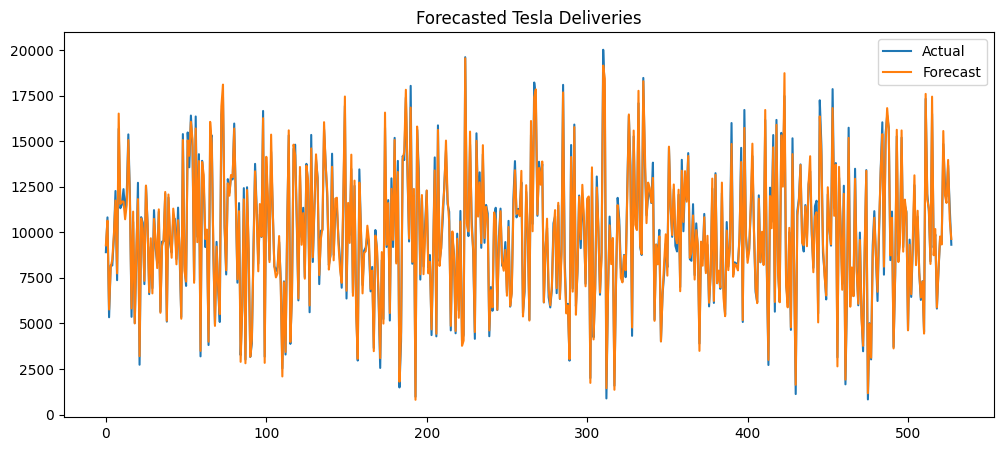

In [32]:
plt.figure(figsize=(12,5))

plt.plot(  y_test.values,label="Actual")

plt.plot(future_predictions,   label="Forecast")

plt.legend()

plt.title("Forecasted Tesla Deliveries")

plt.show()